# **EDA on University Dataset**

In [3]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### **Loading Data and Shape Exploartion**

In [47]:
# loading data
df = pd.read_csv("University dataset.csv")
df.head()

,Student_ID,Age,Gender,Nationality,Program,Major_Specialization,Year_of_Study,Enrollment_Type,GPA,High_School_GPA,...,Financial_Aid,Family_Income,Parental_Education_Level,Health_Insurance,Mental_Health_Support_Used,Academic_Probation,Dropout_Risk_Score,Graduation_Expected_Year,Employment_Offer,Starting_Salary_Offer
0,1,30,Female,Canada,Mathematics,Cybersecurity,5,FullTime,2.99,3.53,...,No,126717.0,PhD,Yes,No,No,1.000,2027,No,0.0
1,2,19,Male,Canada,AI,Finance,2,FullTime,3.37,3.43,...,No,215708.0,Master,No,No,No,0.565,2028,Yes,45143.0
2,3,19,Female,UK,Physics,Marketing,2,PartTime,3.34,3.07,...,No,68245.0,HighSchool,No,No,No,0.670,2026,No,0.0
3,4,23,Male,Australia,Economics,Cybersecurity,1,FullTime,2.55,4.00,...,No,110478.0,PhD,Yes,No,No,0.352,2026,Yes,34040.0
4,5,34,Male,UAE,Computer Science,Robotics,5,PartTime,2.94,3.22,...,Yes,292894.0,HighSchool,No,No,No,0.662,2029,Yes,36345.0


In [48]:
# learning more about our data
columns = df.columns
shape = df.shape

print("Number of Rows: ", shape[0])
print("Number of Columns: ", shape[1], end="\n\n")
print("Feature Names: ", columns)

Number of Rows:  3000
Number of Columns:  40

Feature Names:  Index(['Student_ID', 'Age', 'Gender', 'Nationality', 'Program',
       'Major_Specialization', 'Year_of_Study', 'Enrollment_Type', 'GPA',
       'High_School_GPA', 'SAT_Score', 'Credits_Completed',
       'Credits_This_Semester', 'Scholarship_Status', 'Scholarship_Amount',
       'Accommodation_Type', 'Distance_From_Campus_km', 'Attendance_Rate',
       'Study_Hours_Per_Week', 'Part_Time_Job', 'Weekly_Work_Hours',
       'Internship_Completed', 'Internship_Count', 'Clubs_Joined',
       'Leadership_Role', 'Online_Courses_Taken', 'Research_Participation',
       'Publications_Count', 'Exchange_Program', 'English_Proficiency_Score',
       'Financial_Aid', 'Family_Income', 'Parental_Education_Level',
       'Health_Insurance', 'Mental_Health_Support_Used', 'Academic_Probation',
       'Dropout_Risk_Score', 'Graduation_Expected_Year', 'Employment_Offer',
       'Starting_Salary_Offer'],
      dtype='object')


### **Cleaning nulls**

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  3000 non-null   int64  
 1   Age                         3000 non-null   int64  
 2   Gender                      3000 non-null   object 
 3   Nationality                 3000 non-null   object 
 4   Program                     3000 non-null   object 
 5   Major_Specialization        3000 non-null   object 
 6   Year_of_Study               3000 non-null   int64  
 7   Enrollment_Type             3000 non-null   object 
 8   GPA                         3000 non-null   float64
 9   High_School_GPA             2775 non-null   float64
 10  SAT_Score                   2657 non-null   float64
 11  Credits_Completed           3000 non-null   int64  
 12  Credits_This_Semester       3000 non-null   int64  
 13  Scholarship_Status          3000 

In [50]:
print(df.isnull().sum().to_string())

Student_ID                      0
Age                             0
Gender                          0
Nationality                     0
Program                         0
Major_Specialization            0
Year_of_Study                   0
Enrollment_Type                 0
GPA                             0
High_School_GPA               225
SAT_Score                     343
Credits_Completed               0
Credits_This_Semester           0
Scholarship_Status              0
Scholarship_Amount            310
Accommodation_Type              0
Distance_From_Campus_km       194
Attendance_Rate               191
Study_Hours_Per_Week          191
Part_Time_Job                   0
Weekly_Work_Hours             279
Internship_Completed            0
Internship_Count                0
Clubs_Joined                    0
Leadership_Role                 0
Online_Courses_Taken            0
Research_Participation          0
Publications_Count              0
Exchange_Program                0
English_Profic

In [51]:
# We learn from .info() that a few features have missing values and we have three data types = object, int64 and float64

# let's deal with null values
df['High_School_GPA'].fillna(df['High_School_GPA'].mean(), inplace=True)
df['SAT_Score'].fillna(df['SAT_Score'].mean(), inplace=True)
df['Distance_From_Campus_km'].fillna(df['Distance_From_Campus_km'].median(), inplace=True)
df['Attendance_Rate'].fillna(df['Attendance_Rate'].median(), inplace=True)
df['Study_Hours_Per_Week'].fillna(df['Study_Hours_Per_Week'].median(), inplace=True)
df['English_Proficiency_Score'].fillna(df['English_Proficiency_Score'].mean(), inplace=True)
df['Family_Income'].fillna(df['Family_Income'].median(), inplace=True)
df['Parental_Education_Level'] = df['Parental_Education_Level'].fillna("Unknown")

In [52]:
# these require further checking, as they depend on other features
avg_sch = df.loc[df['Scholarship_Status'] == 'Yes', 'Scholarship_Amount'].mean()
mean_hours = df.loc[df['Part_Time_Job'] == 'Yes', 'Weekly_Work_Hours'].mean()
median_salary = df.loc[df['Employment_Offer'] == 'Yes', 'Starting_Salary_Offer'].median()

df['Scholarship_Amount'] = np.where(df['Scholarship_Status'] == 'No', 0,
                           np.where(df['Scholarship_Amount'].isna(), avg_sch, df['Scholarship_Amount']))

df['Weekly_Work_Hours'] = np.where(df['Part_Time_Job'] == 'No', 0,
                          np.where(df['Weekly_Work_Hours'].isna(), mean_hours, df['Weekly_Work_Hours']))

df['Starting_Salary_Offer'] = np.where(df['Employment_Offer'] == 'No', 0,
                              np.where(df['Starting_Salary_Offer'].isna(), median_salary, df['Starting_Salary_Offer']))

In [53]:
print(df.isnull().sum().to_string())

Student_ID                    0
Age                           0
Gender                        0
Nationality                   0
Program                       0
Major_Specialization          0
Year_of_Study                 0
Enrollment_Type               0
GPA                           0
High_School_GPA               0
SAT_Score                     0
Credits_Completed             0
Credits_This_Semester         0
Scholarship_Status            0
Scholarship_Amount            0
Accommodation_Type            0
Distance_From_Campus_km       0
Attendance_Rate               0
Study_Hours_Per_Week          0
Part_Time_Job                 0
Weekly_Work_Hours             0
Internship_Completed          0
Internship_Count              0
Clubs_Joined                  0
Leadership_Role               0
Online_Courses_Taken          0
Research_Participation        0
Publications_Count            0
Exchange_Program              0
English_Proficiency_Score     0
Financial_Aid                 0
Family_I

In [7]:
# let's split categorical and numerical data
categorical = df.select_dtypes(include=["object"])
numerical = df.select_dtypes(include=["float64", "int64"])

### **Exploring Correlation**

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Applying label encoding to each of the categorical columns
for col in categorical:
    df[col] = le.fit_transform(df[col])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  3000 non-null   int64  
 1   Age                         3000 non-null   int64  
 2   Gender                      3000 non-null   int64  
 3   Nationality                 3000 non-null   int64  
 4   Program                     3000 non-null   int64  
 5   Major_Specialization        3000 non-null   int64  
 6   Year_of_Study               3000 non-null   int64  
 7   Enrollment_Type             3000 non-null   int64  
 8   GPA                         3000 non-null   float64
 9   High_School_GPA             2775 non-null   float64
 10  SAT_Score                   2657 non-null   float64
 11  Credits_Completed           3000 non-null   int64  
 12  Credits_This_Semester       3000 non-null   int64  
 13  Scholarship_Status          3000 

<Axes: >

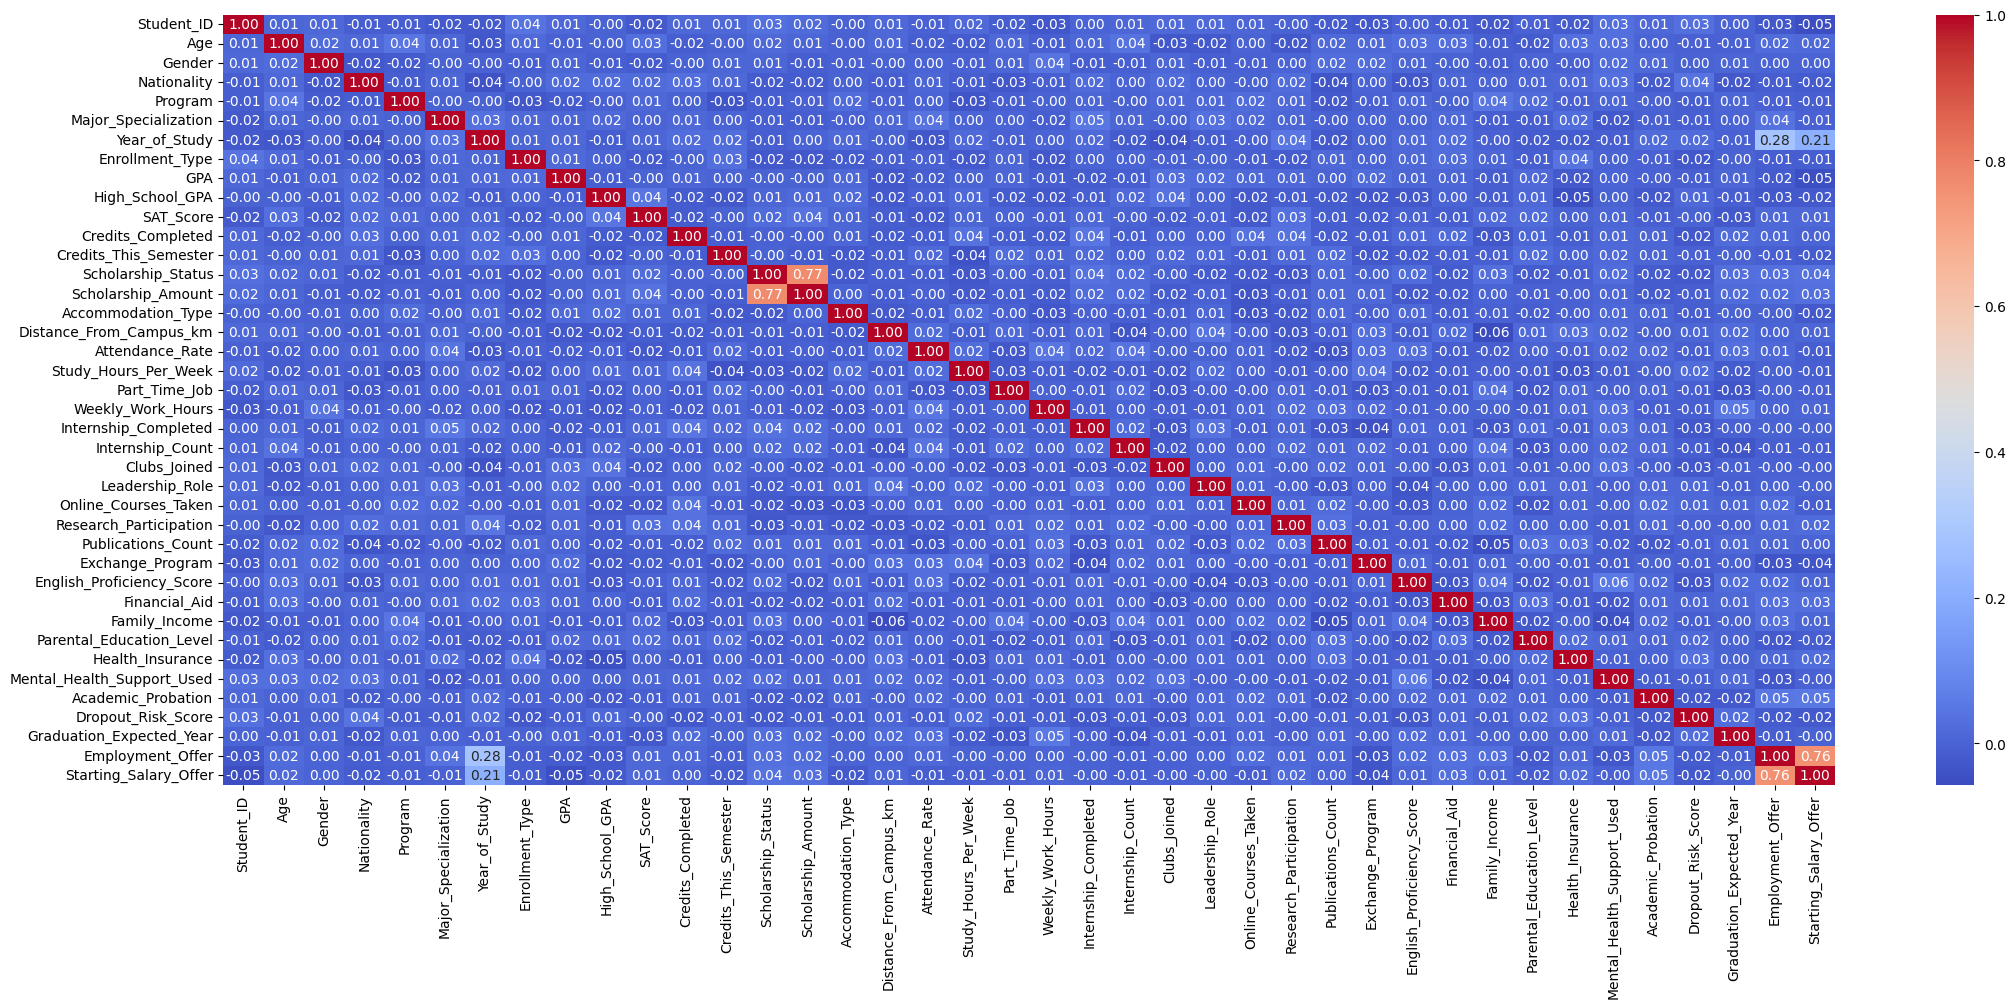

In [9]:
corr_matrix = df.corr()
plt.figure(figsize=(26, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

### **Exploring Distribution**

In [56]:
# encoding categorical values
binary_cols = [
    "Employment_Offer",
    "Internship_Completed",
    "Leadership_Role",
    "Research_Participation",
    "Exchange_Program",
    "Part_Time_Job"
]

for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})

In [71]:
# we will group all features related to student engagement together 
engagement_features = [
    "Study_Hours_Per_Week",
    "Clubs_Joined",
    "Internship_Completed",
    "Internship_Count",
    "Leadership_Role",
    "Online_Courses_Taken",
    "Research_Participation"
]

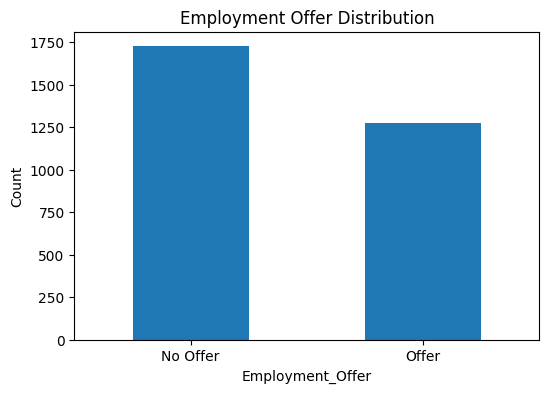

In [72]:
# basic understanding of employability ratio
plt.figure(figsize=(6,4))
df["Employment_Offer"].value_counts().plot(kind="bar")
plt.title("Employment Offer Distribution")
plt.xticks([0,1], ["No Offer", "Offer"], rotation=0)
plt.ylabel("Count")
plt.show()

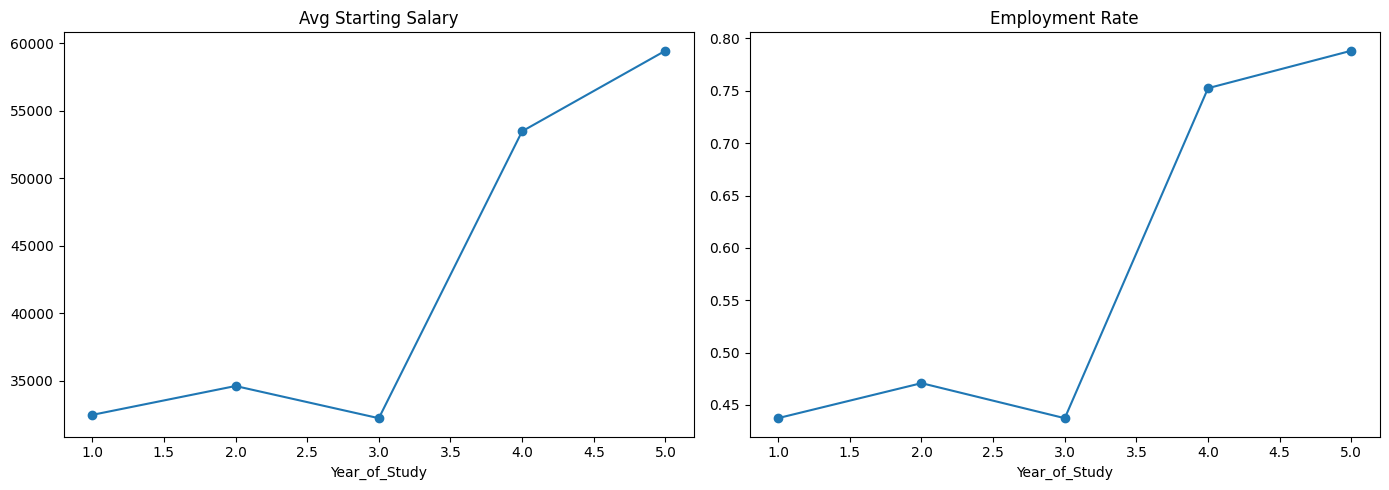

In [80]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

df.groupby("Year_of_Study")["Starting_Salary_Offer"].mean().plot(
    marker="o", ax=ax[0], title="Avg Starting Salary"
)

df.groupby("Year_of_Study")["Employment_Offer"].mean().plot(
    marker="o", ax=ax[1], title="Employment Rate"
)

plt.tight_layout()
plt.show()

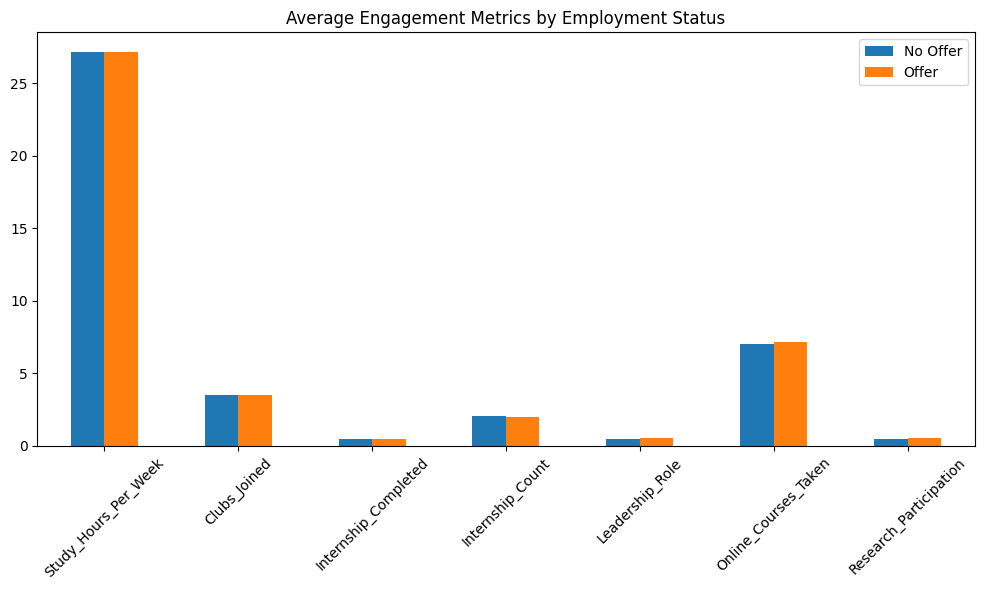

In [73]:
# how does student engagement impact employability?
employment_group = df.groupby("Employment_Offer")[engagement_features].mean().T

employment_group.plot(kind="bar", figsize=(10,6))
plt.title("Average Engagement Metrics by Employment Status")
plt.xticks(rotation=45)
plt.legend(["No Offer", "Offer"])
plt.tight_layout()
plt.show()

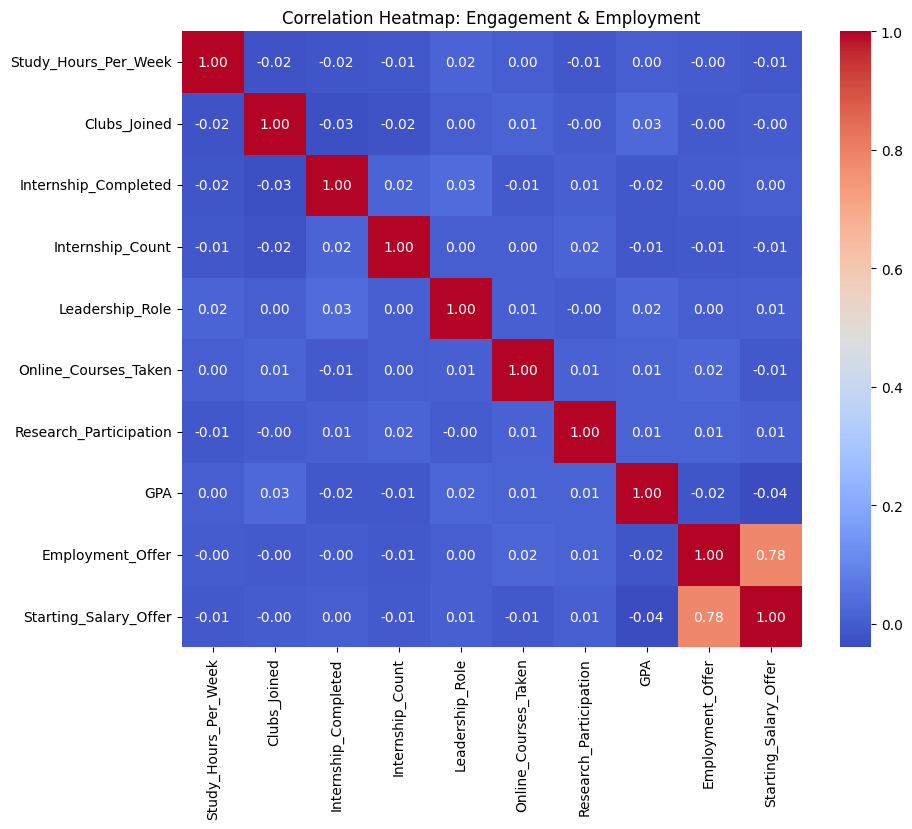

In [74]:
corr_features = engagement_features + ["GPA", "Employment_Offer", "Starting_Salary_Offer"]
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: Engagement & Employment")
plt.show()

### **Export to Import to Tableau**

In [55]:
# export processed data to csv
df.to_csv("Processed University Data.csv", index=False)